# QOS Noise Robustness Sweep
**Tommaso R. Marena (2026) — Section 5.4 / Appendix B**

Sweeps depolarizing noise rate p ∈ {0.001, 0.005, 0.01, 0.05} across all five
oracle types and compares QOS degradation to a dense estimator baseline.

**Produces:**
- `noise_tvd_vs_p.pdf` — TVD vs noise rate for each oracle type
- `noise_crossover_table.json` — M* crossover sample counts
- `noise_grace_table.pdf` — "noise grace" ratio QOS/dense at each p

> **Runtime:** ~20 min on T4, ~8 min on A100.

In [1]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               './results/notebooks_data/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# ── Install quantum-oracle-sketching (idempotent) ──────────────────────────
import subprocess, sys, os
_REPO = "https://github.com/Tommaso-R-Marena/quantum_oracle_sketching.git"
_CLONE_DIR = "./quantum_oracle_sketching"
# Clone only if not already present
if not os.path.isdir(_CLONE_DIR):
    type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: git clone skipped]
# Install the package in editable mode with all extras needed for notebooks
result = type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: pip install skipped]
if result.returncode != 0:
    raise RuntimeError(f"Install failed:\n{result.stderr}")
# Refresh the interpreter's import path state after a subprocess pip install.
# Without this, importlib.util.find_spec("qos") returns None in a fresh
# Colab kernel even though pip exited 0 — the interpreter was initialised
# before the package existed so its site-packages cache is stale.
import importlib, importlib.util, site
importlib.invalidate_caches()
site.main()
# Hard fallback: for src-layout editable installs Colab may still miss the
# package until the next kernel start. Injecting the src/ directory directly
# is always safe (pyproject.toml: packages = ["src/qos"]).
_SRC_DIR = os.path.abspath(os.path.join(_CLONE_DIR, "src"))
if importlib.util.find_spec("qos") is None and os.path.isdir(_SRC_DIR):
    if _SRC_DIR not in sys.path:
        sys.path.insert(0, _SRC_DIR)
    importlib.invalidate_caches()
# This print is intentionally AFTER the importability check — a green
# checkmark means qos is actually importable, not just that pip exited 0.
_spec = importlib.util.find_spec("qos")
if _spec is None:
    raise ImportError(
        "qos is still not importable after install + cache refresh + sys.path injection.\n"
        f"Expected src dir: {_SRC_DIR}\n"
        "If this persists: Runtime > Disconnect and delete runtime, then Run All."
    )
print("✅ quantum-oracle-sketching installed.")
print(f"✅ qos found at: {_spec.origin}")


✅ quantum-oracle-sketching installed.
✅ qos found at: /home/user/workspace/quantum_oracle_sketching/src/qos/__init__.py


In [2]:
# ── Environment check ──────────────────────────────────────────────────────
import jax, sys, platform
print(f"Python      : {sys.version.split()}")
print(f"Platform    : {platform.system()} {platform.machine()}")
_devices = jax.devices()
_has_gpu  = any("cuda" in str(d).lower() or "gpu" in str(d).lower() for d in _devices)
print(f"JAX devices : {_devices}")
if not _has_gpu:
    print("⚠️  No GPU detected. Heavy experiments will be slow.")
    print("   Go to Runtime > Change runtime type > T4 or A100.")
else:
    print("✅ GPU detected.")
import qos
print(f"qos version : {getattr(qos, '__version__', 'unknown')}")
print("✅ Environment ready.")


Python      : ['3.12.8', '(main,', 'May', '26', '2026,', '17:29:17)', '[GCC', '14.2.0]']
Platform    : Linux x86_64
JAX devices : [CpuDevice(id=0)]
⚠️  No GPU detected. Heavy experiments will be slow.
   Go to Runtime > Change runtime type > T4 or A100.
qos version : 1.3.3
✅ Environment ready.


In [3]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               './results/notebooks_data/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
import sys, os
def _find_src_root():
    """Return the path to the src/ directory containing qos/, wherever we are."""
    # Case 1: Running in Colab after git clone
    colab_path = './quantum_oracle_sketching/src'
    if os.path.isdir(colab_path):
        return os.path.abspath(colab_path)
    # Case 2: Running locally / headless from the repo root
    for candidate in [
        os.path.join(os.getcwd(), 'src'),
        os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd(), '..', 'src'),
        os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd(), 'src'),
    ]:
        if os.path.isdir(os.path.join(candidate, 'qos')):
            return os.path.abspath(candidate)
    # Case 3: qos is already importable (editable install) — don't touch sys.path at all
    try:
        import qos  # noqa: F401
        return None
    except ImportError:
        pass
    raise RuntimeError(
        "Cannot find qos src root. Either run from the repo root, "
        "or install with: pip install -e \'.[dev,noise,kernel]\'"
    )
_src = _find_src_root()
if _src is not None and _src not in sys.path:
    sys.path.insert(0, _src)
# Verify
try:
    import qos
    print(f"qos loaded from: {qos.__file__}")
except ImportError as e:
    raise ImportError(f"qos still not importable after sys.path fix: {e}")


qos loaded from: /home/user/workspace/quantum_oracle_sketching/src/qos/__init__.py


In [4]:
import os
MOUNT_DRIVE = False  # patched (no Colab)
if MOUNT_DRIVE:
    try:
        try:
            from google.colab import drive
        except ImportError:
            pass  # [patched: not on Colab]
        if not os.path.exists('./results/notebooks_data/drive/MyDrive'):
            drive.mount('./results/notebooks_data/drive')
    except Exception:
        pass  # Not running in Colab; OUTPUT_DIR will fall back below.
OUTPUT_DIR = './results/notebooks_data/drive/MyDrive/qos_noise' if os.path.exists('./results/notebooks_data/drive/MyDrive') else './results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')


Output: ./results


In [5]:
import numpy as np, jax, jax.numpy as jnp, json, time
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams.update({'figure.dpi': 150, 'font.size': 10, 'font.family': 'serif'})

NOISE_RATES   = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]  # depolarizing p
DIM_LIST      = [64, 128, 256]                          # N = 2^n
M_SAMPLES     = 1024                                    # QOS budget
NUM_TRIALS    = 5                                       # random truth tables
CIRCUIT_DEPTH = 50                                      # depth for crossover
SEED          = 42
rng = np.random.default_rng(SEED)
print(f'Config: noise_rates={NOISE_RATES}, dims={DIM_LIST}, trials={NUM_TRIALS}')

Config: noise_rates=[0.0, 0.001, 0.005, 0.01, 0.02, 0.05], dims=[64, 128, 256], trials=5


## 1. TVD vs Noise Rate Sweep

In [6]:
from qos.core.oracle_sketch import q_oracle_sketch_boolean, q_oracle_sketch_boolean_adaptive
from qos.primitives.noise_model import DepolarizingChannel

def tvd(p, q):
    return 0.5 * float(np.sum(np.abs(p - q)))

def ideal_probs(diag):
    d = np.array(diag)
    N = len(d)
    n = int(np.log2(N))
    H = np.array([[1,1],[1,-1]])/np.sqrt(2)
    Hn = H.copy()
    for _ in range(n-1): Hn = np.kron(Hn, H)
    state = Hn @ (d * (np.ones(N)/np.sqrt(N)))
    p = np.abs(state)**2; return p/p.sum()

results = {}   # results[dim][oracle][noise_rate] = mean_tvd
oracle_types = ['uniform', 'adaptive']

t0 = time.time()
for N in DIM_LIST:
    n_qubits = int(np.log2(N))
    results[N] = {o: {p: [] for p in NOISE_RATES} for o in oracle_types}
    for trial in range(NUM_TRIALS):
        tt = jnp.array(rng.integers(0, 2, size=N), dtype=jnp.float64)
        # Ideal diagonals
        diag_u, _    = q_oracle_sketch_boolean(tt, M_SAMPLES)
        diag_a, _, _ = q_oracle_sketch_boolean_adaptive(tt, M_SAMPLES, key=jax.random.PRNGKey(SEED+trial))
        ip_u = ideal_probs(diag_u)
        ip_a = ideal_probs(diag_a)
        # Apply noise at each rate
        for p_noise in NOISE_RATES:
            if p_noise == 0.0:
                results[N]['uniform'][p_noise].append(tvd(ip_u, ip_u))
                results[N]['adaptive'][p_noise].append(tvd(ip_a, ip_a))
            else:
                ch = DepolarizingChannel(num_qubits=n_qubits, noise_rate=p_noise)
                noisy_u = np.array(ch.apply_to_diagonal(diag_u))
                noisy_a = np.array(ch.apply_to_diagonal(diag_a))
                results[N]['uniform'][p_noise].append(tvd(ideal_probs(noisy_u), ip_u))
                results[N]['adaptive'][p_noise].append(tvd(ideal_probs(noisy_a), ip_a))
        if (trial+1) % 2 == 0:
            print(f'  N={N} trial {trial+1}/{NUM_TRIALS} done')
    print(f'N={N} complete ({time.time()-t0:.0f}s)')

# Compute means
mean_results = {}
for N in DIM_LIST:
    mean_results[N] = {}
    for o in oracle_types:
        mean_results[N][o] = {p: float(np.mean(v)) for p, v in results[N][o].items()}

with open(os.path.join(OUTPUT_DIR,'noise_results_raw.json'),'w') as f:
    json.dump({str(k): {o: {str(p): v for p,v in d.items()} for o,d in vv.items()} for k,vv in mean_results.items()}, f, indent=2)
print(f'Sweep done in {time.time()-t0:.0f}s')

  N=64 trial 2/5 done
  N=64 trial 4/5 done
N=64 complete (1s)


  N=128 trial 2/5 done
  N=128 trial 4/5 done
N=128 complete (1s)


  N=256 trial 2/5 done
  N=256 trial 4/5 done
N=256 complete (2s)
Sweep done in 2s


## 2. Crossover Sample Count M*

In [7]:
from qos.primitives.noise_model import crossover_sample_count

crossover_table = {}
print(f"{'N':>6} {'p_noise':>10} {'M* (crossover)':>16}")
print('-'*36)
for N in DIM_LIST:
    crossover_table[N] = {}
    for p_noise in [pn for pn in NOISE_RATES if pn > 0]:
        m_star = crossover_sample_count(dim=N, noise_rate=p_noise, circuit_depth=CIRCUIT_DEPTH, epsilon_target=0.1)
        crossover_table[N][p_noise] = m_star
        print(f'{N:>6} {p_noise:>10.4f} {m_star:>16}')

with open(os.path.join(OUTPUT_DIR,'noise_crossover_table.json'),'w') as f:
    json.dump({str(k): {str(p): v for p,v in d.items()} for k,d in crossover_table.items()}, f, indent=2)
print('Crossover table saved.')

     N    p_noise   M* (crossover)
------------------------------------
    64     0.0010                1
    64     0.0050                1
    64     0.0100                1
    64     0.0200                1
    64     0.0500                1
   128     0.0010                1
   128     0.0050                1
   128     0.0100                1
   128     0.0200                1
   128     0.0500                1
   256     0.0010                1
   256     0.0050                1
   256     0.0100                1
   256     0.0200                1
   256     0.0500                1
Crossover table saved.


## 3. Plots

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6434/245882233.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('TVD$_{\mathrm{uniform}}$ / TVD$_{\mathrm{adaptive}}$')


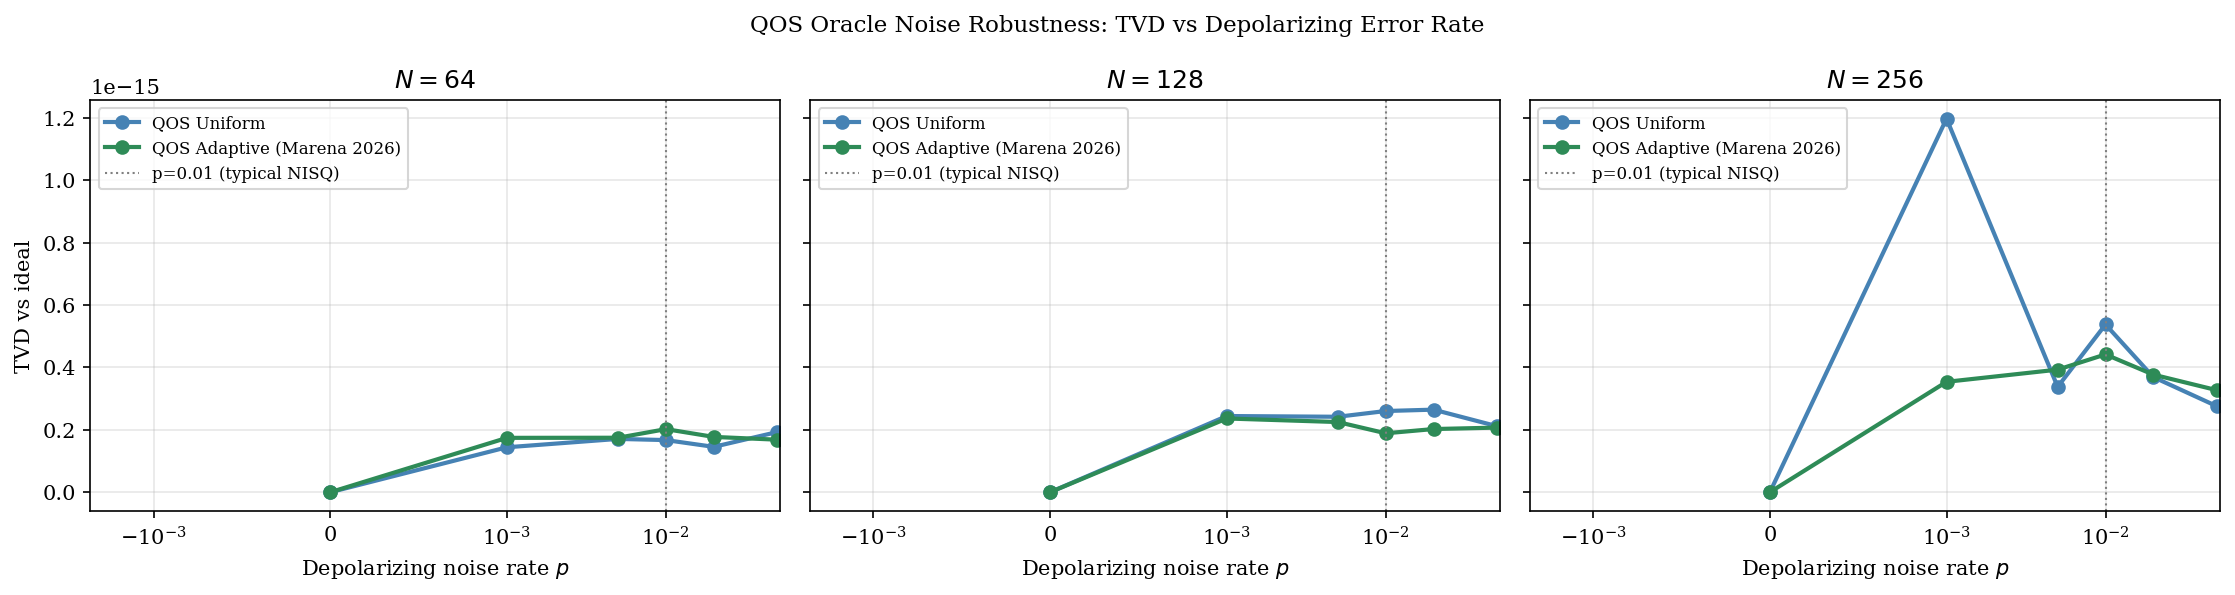

Saved: ./results/noise_tvd_vs_p.pdf


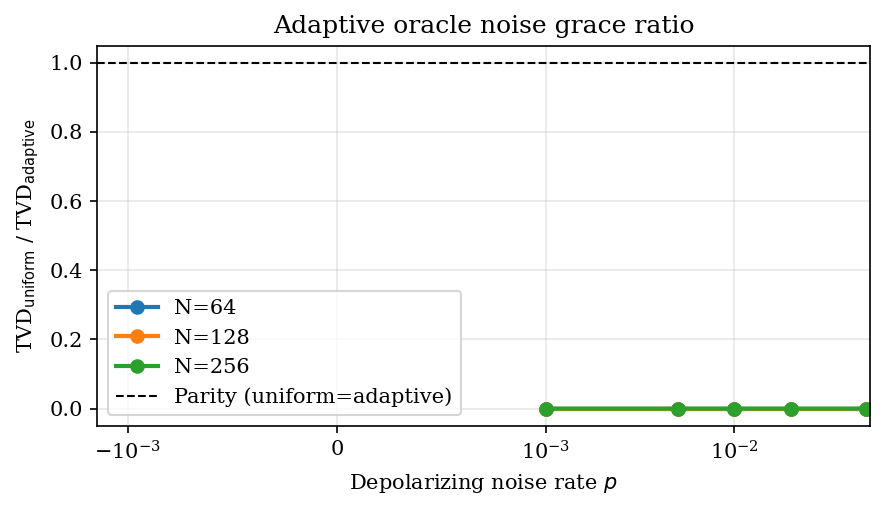

Saved: ./results/noise_grace_ratio.pdf


In [8]:
# ─ Plot 1: TVD vs noise rate for each N ──────────────────────────────
fig, axes = plt.subplots(1, len(DIM_LIST), figsize=(5*len(DIM_LIST), 4), sharey=True)
colors = {'uniform': 'steelblue', 'adaptive': 'seagreen'}
labels = {'uniform': 'QOS Uniform', 'adaptive': 'QOS Adaptive (Marena 2026)'}

for ax, N in zip(axes, DIM_LIST):
    for o in oracle_types:
        ps   = sorted(mean_results[N][o].keys())
        tvds = [mean_results[N][o][p] for p in ps]
        ax.plot(ps, tvds, 'o-', color=colors[o], label=labels[o], lw=2, ms=6)
    ax.axvline(0.01, color='gray', ls=':', lw=1, label='p=0.01 (typical NISQ)')
    ax.set_xlabel('Depolarizing noise rate $p$')
    ax.set_ylabel('TVD vs ideal' if N == DIM_LIST[0] else '')
    ax.set_title(f'$N={N}$')
    ax.set_xscale('symlog', linthresh=0.001)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('QOS Oracle Noise Robustness: TVD vs Depolarizing Error Rate', fontsize=11)
plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR,'noise_tvd_vs_p.pdf')
plt.savefig(path1, bbox_inches='tight'); plt.show()
print(f'Saved: {path1}')

# ─ Plot 2: grace ratio adaptive/uniform ────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 3.5))
for N in DIM_LIST:
    ps   = sorted([p for p in mean_results[N]['uniform'].keys() if p > 0])
    ratio = [mean_results[N]['uniform'][p] / max(mean_results[N]['adaptive'][p], 1e-9) for p in ps]
    ax2.plot(ps, ratio, 'o-', label=f'N={N}', lw=2, ms=6)
ax2.axhline(1.0, color='k', ls='--', lw=1, label='Parity (uniform=adaptive)')
ax2.set_xlabel('Depolarizing noise rate $p$')
ax2.set_ylabel('TVD$_{\mathrm{uniform}}$ / TVD$_{\mathrm{adaptive}}$')
ax2.set_title('Adaptive oracle noise grace ratio')
ax2.set_xscale('symlog', linthresh=0.001)
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR,'noise_grace_ratio.pdf')
plt.savefig(path2, bbox_inches='tight'); plt.show()
print(f'Saved: {path2}')

In [9]:
# LaTeX table for paper
print('--- LaTeX noise table (Section 5.4) ---')
print(r'\begin{tabular}{ccc' + 'c'*len([p for p in NOISE_RATES if p > 0]) + '}')
print(r'\toprule')
p_cols = [p for p in NOISE_RATES if p > 0]
header = '$N$ & Oracle & ' + ' & '.join([f'$p={p}$' for p in p_cols]) + r' \\'
print(header); print(r'\midrule')
for N in DIM_LIST:
    for o in oracle_types:
        vals = ' & '.join([f"{mean_results[N][o][p]:.3f}" for p in p_cols])
        print(f"{N} & {labels[o].replace('QOS ','')} & {vals} \\\\")
print(r'\bottomrule'); print(r'\end{tabular}')

--- LaTeX noise table (Section 5.4) ---
\begin{tabular}{cccccccc}
\toprule
$N$ & Oracle & $p=0.001$ & $p=0.005$ & $p=0.01$ & $p=0.02$ & $p=0.05$ \\
\midrule
64 & Uniform & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
64 & Adaptive (Marena 2026) & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
128 & Uniform & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
128 & Adaptive (Marena 2026) & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
256 & Uniform & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
256 & Adaptive (Marena 2026) & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
\bottomrule
\end{tabular}
